In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import load_wine

In [ ]:
wine = load_wine()

In [ ]:
df = pd.DataFrame(wine.data, columns = wine.feature_names)
df['target'] = wine['target']
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
df['target'].value_counts()

1    71
0    59
2    48
Name: target, dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(df.drop('target', axis = 1))

StandardScaler()

In [ ]:
scaled_values = scaler.transform(df.drop('target', axis = 1))

In [ ]:
scaled_values

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

In [ ]:
df_features = pd.DataFrame(scaled_values, columns = df.columns[:-1])

In [ ]:
df_features.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [ ]:
X = df_features
Y = df['target']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 101)

In [ ]:
len(X_test)

54

In [ ]:
err_rates = []

for k in range(1,41):
  knn = KNeighborsClassifier(n_neighbors = k)
  knn.fit(X_train, Y_train)
  predict_k = knn.predict(X_test)
  err_rates.append(np.mean(predict_k != Y_test))

Text(0, 0.5, 'Error Rate')

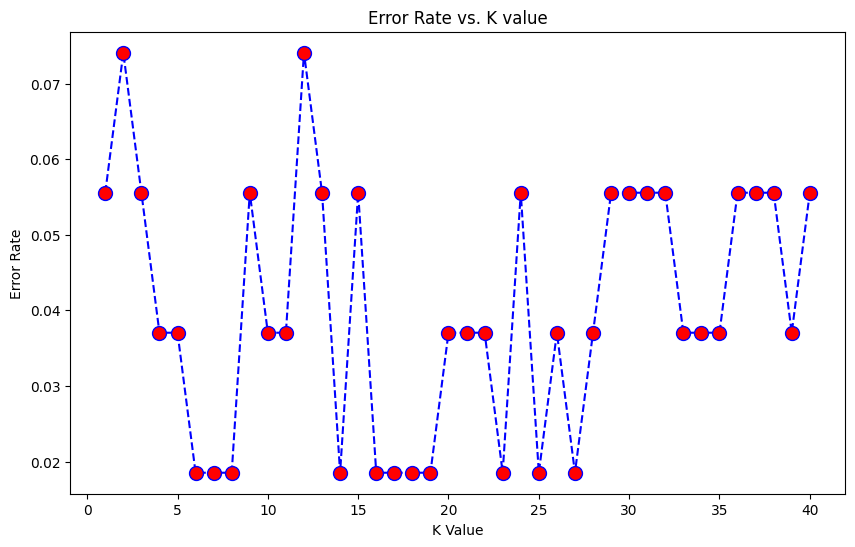

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(1,41), err_rates, color = 'blue', linestyle = 'dashed', marker = 'o', markerfacecolor = 'red', markersize = 10)
plt.title('Error Rate vs. K value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')

In [ ]:
knn = KNeighborsClassifier(n_neighbors = 25)
knn.fit(X_train, Y_train)
predict = knn.predict(X_test)

In [ ]:
print('accuracy', accuracy_score(Y_test, predict))

accuracy 0.9814814814814815


In [ ]:
print('confusion matrix:\n')
print(confusion_matrix(Y_test, predict))

confusion matrix:

[[19  0  0]
 [ 0 21  1]
 [ 0  0 13]]


In [ ]:
print('classification report:\n')
print(classification_report(Y_test, predict))

classification report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        22
           2       0.93      1.00      0.96        13

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



###DECISION TREES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
%matplotlib inline


In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

In [ ]:
df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df['target'].value_counts()

0    50
1    50
2    50
Name: target, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

x = df.drop('target', axis = 1)
y = df['target']

X_train, x_test, Y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 101)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train, Y_train)

DecisionTreeClassifier()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix



array([0, 0, 0, 1, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0,
       1, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 0, 0, 0, 2,
       1])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[13  0  0]
 [ 0 19  1]
 [ 0  1 11]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=100) #number of decision trees
rfc.fit(X_train,Y_train)

RandomForestClassifier()

In [ ]:
rfc_pred = rfc.predict(x_test)

In [ ]:
print(accuracy_score(y_test, rfc_pred))

0.9555555555555556


In [ ]:
print(confusion_matrix(y_test,rfc_pred))

[[13  0  0]
 [ 0 19  1]
 [ 0  1 11]]


In [ ]:
print(classification_report(y_test, rfc_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



###Hyper Parameter Tuning


In [ ]:
print(accuracy_score(y_test, y_pred))

0.9555555555555556


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {'max_depth': [10,20,30,40,50,100,150,200],
              'min_samples_split': [2,3,4,5,6,7,8],
              'criterion': ['gini', 'entropy']
}

In [ ]:
grid = GridSearchCV(dtc, param_grid = param_grid, verbose = 3, refit = True)
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 112 candidates, totalling 560 fits
[CV 1/5] END criterion=gini, max_depth=10, min_samples_split=2;, score=1.000 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=10, min_samples_split=2;, score=0.905 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=10, min_samples_split=2;, score=0.952 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=10, min_samples_split=2;, score=0.952 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=10, min_samples_split=2;, score=0.952 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=10, min_samples_split=3;, score=1.000 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=10, min_samples_split=3;, score=0.905 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=10, min_samples_split=3;, score=0.905 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=10, min_samples_split=3;, score=0.952 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=10, min_samples_split=3;, score=0.

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 20, 30, 40, 50, 100, 150, 200],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8]},
             verbose=3)

In [ ]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 4}

In [ ]:
grid_preds = grid.predict(x_test)

In [ ]:
grid_preds

array([0, 0, 0, 2, 1, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 1, 1, 1, 0, 2, 1, 0,
       1, 1, 1, 1, 1, 2, 0, 0, 2, 1, 2, 1, 2, 1, 1, 1, 1, 2, 0, 0, 0, 2,
       1])

In [ ]:
print(accuracy_score(y_test, grid_preds))

0.9777777777777777


In [ ]:
!pip install scikit-optimize

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 3.7 MB/s eta 0:00:00


In [ ]:
from skopt import BayesSearchCV

In [ ]:
search_space = {'max_depth': (1,200),
              'min_samples_split': (1,10),
              'criterion': ['gini', 'entropy']
}



In [ ]:
opt = BayesSearchCV(
    estimator = dtc,
    search_spaces = search_space,
    scoring = 'neg_mean_squared_error',
    n_iter = 5,
    random_state = 100,
)

In [ ]:
opt.fit(x_test, grid_preds)

BayesSearchCV(estimator=DecisionTreeClassifier(), n_iter=5, random_state=100,
              scoring='neg_mean_squared_error',
              search_spaces={'criterion': ['gini', 'entropy'],
                             'max_depth': (1, 200),
                             'min_samples_split': (1, 10)})

In [ ]:
bay_preds = opt.predict(x_test)

In [ ]:
print(accuracy_score(y_test, bay_preds))

0.9777777777777777
